# CelebA Dataset Analysis

## Abstract

Project analyzes the CelebA dataset, which contains face images. 
The goal is to explore patterns in facial attributes, discover relationships between gender, makeup, attractiveness and other features and test hypotheses about these relationships.

**Contribution:**
- *Anastasiia* — 
- *Elena* — 

## Dataset loading

Loading the CelebA attributes file using pandas. 

CelebA contains 202 599 face images with 40 binary attributes each (such as Smiling, Male, Young, Attractive, etc.).

Values are encoded as 1 (attribute present) and -1 (attribute absent).

Skipping the first row since it contains only the total image count and using image filename as the index.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('data/list_attr_celeba.txt', skiprows=1, sep='\s+', index_col=0)

df.head()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


## Dataset overview

Checking the basic structure of the dataset: 
1. the number of rows and columns
2. the full list of attributes
3. missing values

In [2]:
print("Dataset size:", df.shape)

print("\nAll attributes:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset size: (202599, 40)

All attributes:
['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']

Missing values:
0


The dataset contains 202,599 images with 40 attributes each. 
No missing values were found, meaning the dataset is complete and ready for analysis.

## Data cleanup

Dataset uses 1 and -1 as binary values, so converting them to 1 and 0 for easier analysis and visualization. 

Verifying that all columns have the correct data type (integer).

In [3]:
df_clean = df.replace(-1, 0)

print("Data types:")
print(df_clean.dtypes.value_counts())

print("\nUnique values in dataset:")
print(df_clean.stack().unique())

df_clean.head()

Data types:
int64    40
Name: count, dtype: int64

Unique values in dataset:
[0 1]


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


## Data transformation

Create 4 new numerical columns based on existing binary attributes.

In [4]:
original_cols = df.columns.tolist()
df_clean['attr_sum'] = df_clean[original_cols].sum(axis=1)

makeup_cols = ['Heavy_Makeup', 'Wearing_Lipstick', 'Rosy_Cheeks', 
               'Wearing_Earrings', 'Wearing_Necklace']
df_clean['makeup_score'] = df_clean[makeup_cols].sum(axis=1)

feminine_cols = ['Arched_Eyebrows', 'Heavy_Makeup', 'High_Cheekbones', 
                 'Wearing_Lipstick', 'Wavy_Hair', 'Bangs']
df_clean['femininity_score'] = df_clean[feminine_cols].sum(axis=1)

hair_cols = ['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair']
df_clean['has_hair'] = (df_clean[hair_cols].sum(axis=1) > 0).astype(int)

print("New columns added:")
print(df_clean[['attr_sum', 'makeup_score', 'femininity_score', 'has_hair']].head(10))

New columns added:
            attr_sum  makeup_score  femininity_score  has_hair
000001.jpg        13             3                 4         1
000002.jpg         8             0                 1         1
000003.jpg         8             0                 1         0
000004.jpg         8             3                 1         0
000005.jpg         9             2                 3         0
000006.jpg        11             3                 4         1
000007.jpg        12             0                 0         1
000008.jpg         9             0                 1         1
000009.jpg        15             4                 5         0
000010.jpg         7             2                 4         0


### Descriptive Statistics for new cols

Computation of basic statistics for new 4 numerical columns: 

1) attr_sum
2) makeup_score
3) femininity_score
4) has_hair

This gives an overview of the distribution of these values across the dataset.

In [5]:
stats_cols = ['attr_sum', 'makeup_score', 'femininity_score', 'has_hair']

df_clean[stats_cols].describe().round(2)

,attr_sum,makeup_score,femininity_score,has_hair
count,202599.00,202599.00,202599.00,202599.00
mean,9.03,1.24,2.05,0.62
std,2.94,1.37,1.73,0.49
min,1.00,0.00,0.00,0.00
25%,7.00,0.00,0.00,0.00
50%,9.00,1.00,2.00,1.00
75%,11.00,2.00,4.00,1.00
max,20.00,5.00,6.00,1.00


The average person in the dataset has 9 out of 40 attributes present. 
The makeup_score median is 1, meaning most people have minimal makeup. 
62% of people have a detectable hair color.

### Explanation about new columns and new terms:

**attr_sum** — total count of attributes marked as present (value = 1) for each image. 
Ranges from 1 to 20.

**makeup_score** — sum of makeup-related attributes: 
Heavy_Makeup, Wearing_Lipstick, Rosy_Cheeks, Wearing_Earrings, Wearing_Necklace. 
Ranges from 0 to 5.

**femininity_score** — sum of attributes typically associated with feminine appearance: 
Arched_Eyebrows, Heavy_Makeup, High_Cheekbones, Wearing_Lipstick, Wavy_Hair, Bangs. 
Ranges from 0 to 6. Visualized for women only (Male = 0).

**has_hair** — 1 if the person has any detected hair color (Black_Hair, Blond_Hair, Brown_Hair or Gray_Hair), 0 if bald or hair color not detected.

## Plots and Detailed overview 

Vizualization of distribution of data: numerical columns and the most common attributes in dataset

Relationships between attributes in the dataset. Comparing key attributes across different groups such as gender, attractiveness and makeup usage.

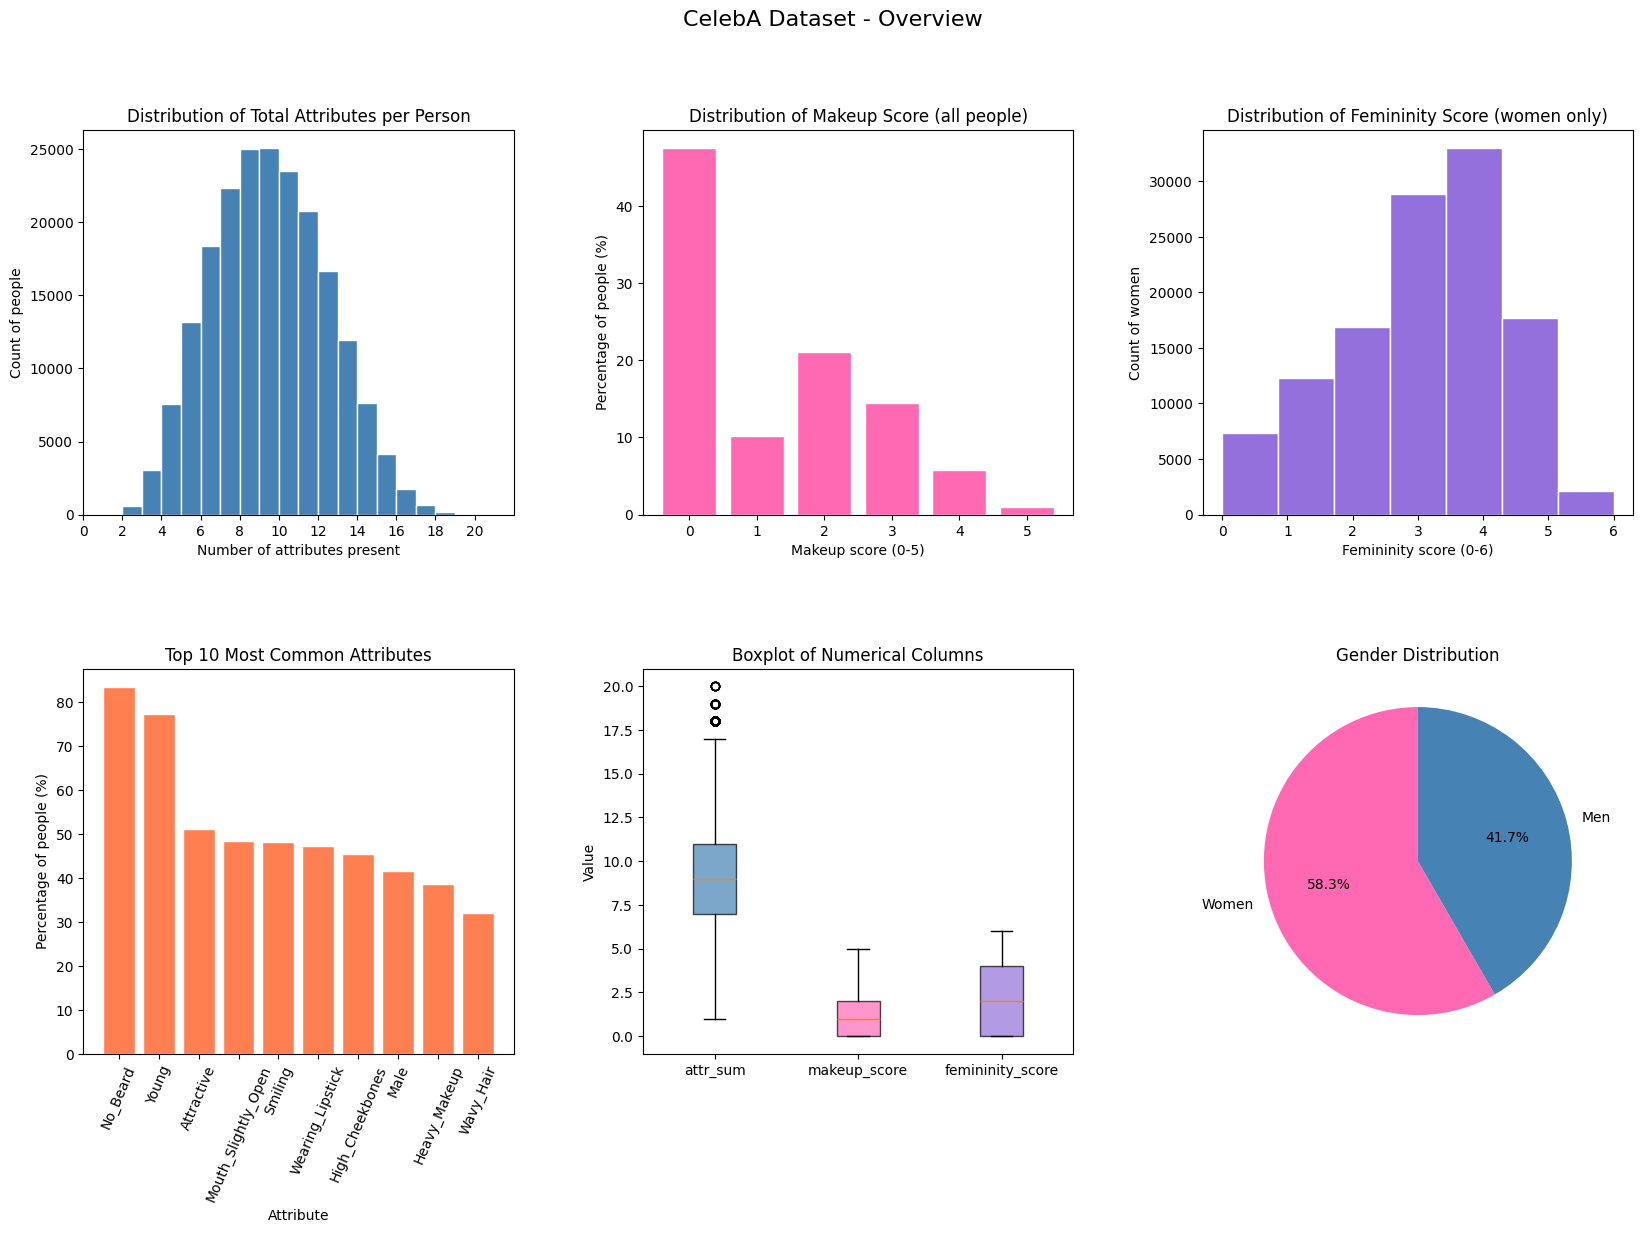

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('CelebA Dataset - Overview', fontsize=16)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Histogram of attr_sum
min_val = int(df_clean['attr_sum'].min())
max_val = int(df_clean['attr_sum'].max())
axes[0, 0].hist(df_clean['attr_sum'], bins=range(min_val, max_val + 2), 
                color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribution of Total Attributes per Person')
axes[0, 0].set_xlabel('Number of attributes present')
axes[0, 0].set_ylabel('Count of people')
axes[0, 0].set_xticks(range(0, max_val + 1, 2))

# 2. Makeup score as percentage
makeup_counts = df_clean['makeup_score'].value_counts(normalize=True).sort_index() * 100
axes[0, 1].bar(makeup_counts.index, makeup_counts.values, color='hotpink', edgecolor='white')
axes[0, 1].set_title('Distribution of Makeup Score (all people)')
axes[0, 1].set_xlabel('Makeup score (0-5)')
axes[0, 1].set_ylabel('Percentage of people (%)')

# 3. Femininity score women only
women = df_clean[df_clean['Male'] == 0]
axes[0, 2].hist(women['femininity_score'], bins=7, color='mediumpurple', edgecolor='white')
axes[0, 2].set_title('Distribution of Femininity Score (women only)')
axes[0, 2].set_xlabel('Femininity score (0-6)')
axes[0, 2].set_ylabel('Count of women')

# 4. Top 10 most common attributes
attr_pct = df_clean[df.columns.tolist()].mean().sort_values(ascending=False).head(10) * 100
axes[1, 0].bar(attr_pct.index, attr_pct.values, color='coral', edgecolor='white')
axes[1, 0].set_title('Top 10 Most Common Attributes')
axes[1, 0].set_xlabel('Attribute')
axes[1, 0].set_ylabel('Percentage of people (%)')
axes[1, 0].tick_params(axis='x', rotation=67)

# 5. Boxplot
bp = axes[1, 1].boxplot(
    [df_clean['attr_sum'], df_clean['makeup_score'], df_clean['femininity_score']],
    tick_labels=['attr_sum', 'makeup_score', 'femininity_score'],
    patch_artist=True
)
colors = ['steelblue', 'hotpink', 'mediumpurple']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Boxplot of Numerical Columns')
axes[1, 1].set_ylabel('Value')

# 6. Pie chart
gender_counts = df_clean['Male'].value_counts()
axes[1, 2].pie(gender_counts.values, 
               labels=['Women', 'Men'],
               colors=['hotpink', 'steelblue'],
               autopct='%1.1f%%',
               startangle=90)
axes[1, 2].set_title('Gender Distribution')

plt.show()

The distribution of attr_sum follows a roughly normal shape centered around 9. 
Approximately half of people have a low makeup_score, which reflects the number of males and females in dataset.
Majority of women have their feminity score at 3-4.
The top 10 most common attributes include Young, No_Beard and Smiling, suggesting the dataset is dominated by young people.

### 1) Top 10 attributes comparison (except 'male') from the 4th plot : men vs women 

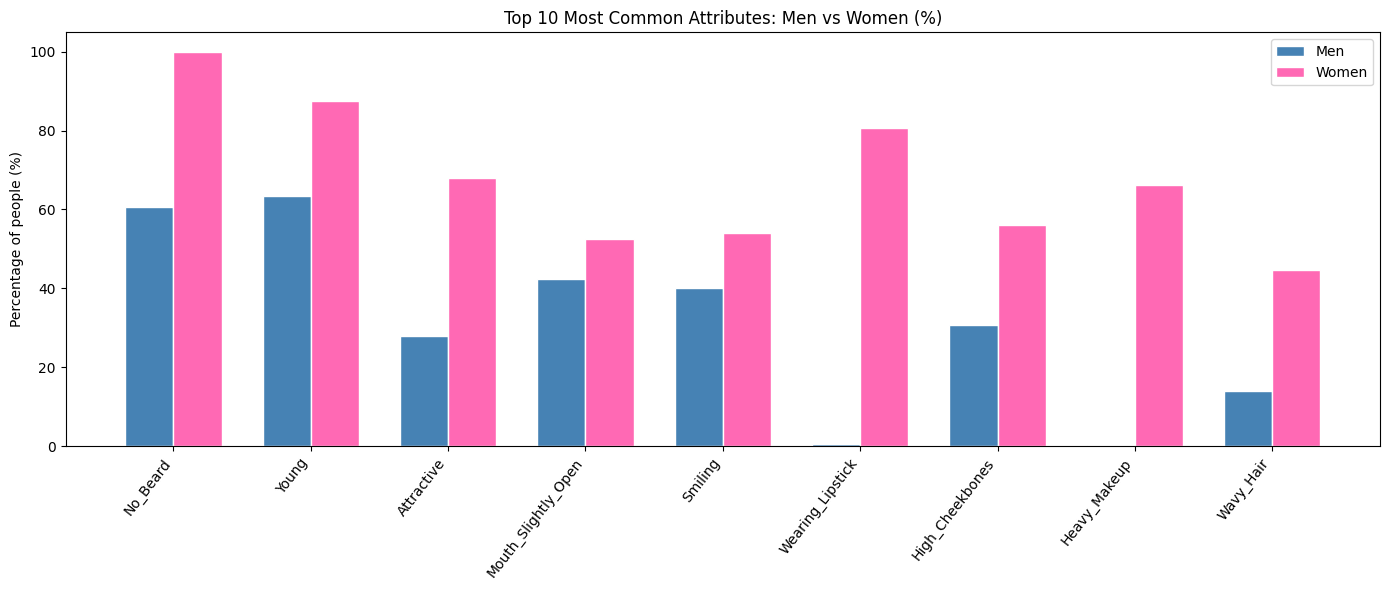

In [7]:
top10_attrs = df_clean[df.columns.tolist()].mean().sort_values(ascending=False).head(10).index.tolist()
top10_attrs = [attr for attr in top10_attrs if attr != 'Male']

men = df_clean[df_clean['Male'] == 1]
women = df_clean[df_clean['Male'] == 0]

men_pct = men[top10_attrs].mean() * 100
women_pct = women[top10_attrs].mean() * 100

x = range(len(top10_attrs))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], men_pct, width, label='Men', color='steelblue', edgecolor='white')
ax.bar([i + width/2 for i in x], women_pct, width, label='Women', color='hotpink', edgecolor='white')

ax.set_title('Top 10 Most Common Attributes: Men vs Women (%)')
ax.set_ylabel('Percentage of people (%)')
ax.set_xticks(x)
ax.set_xticklabels(top10_attrs, rotation=52, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

### 2) Correlation heatmap of selected attributes (how some attributes are correlating/connected to each other)

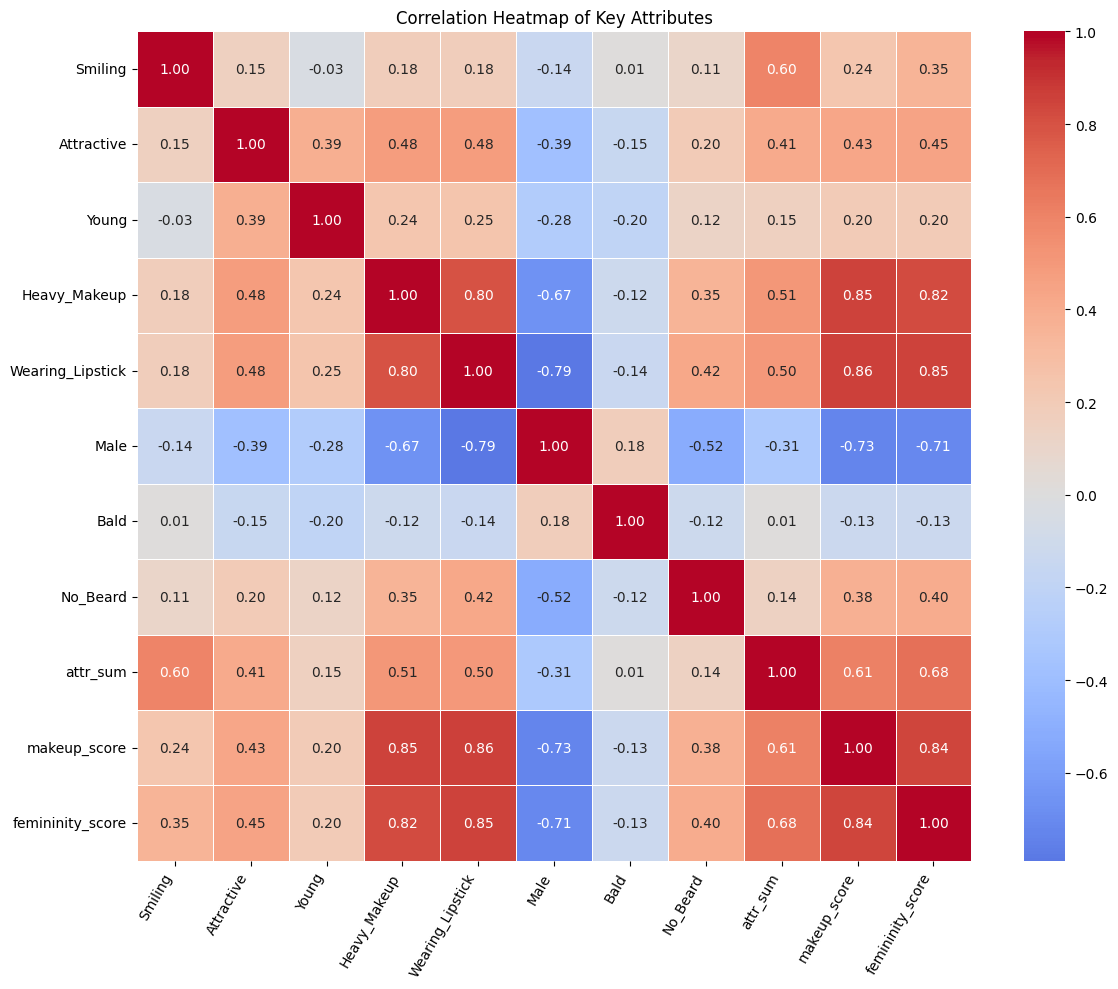

In [8]:
corr_attrs = ['Smiling', 'Attractive', 'Young', 'Heavy_Makeup', 
              'Wearing_Lipstick', 'Male', 'Bald', 'No_Beard',
              'attr_sum', 'makeup_score', 'femininity_score']

corr_matrix = df_clean[corr_attrs].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, linewidths=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
ax.set_title('Correlation Heatmap of Key Attributes')

plt.tight_layout()
plt.show()

### 3) Makeup score and hair colour distribution: men vs women

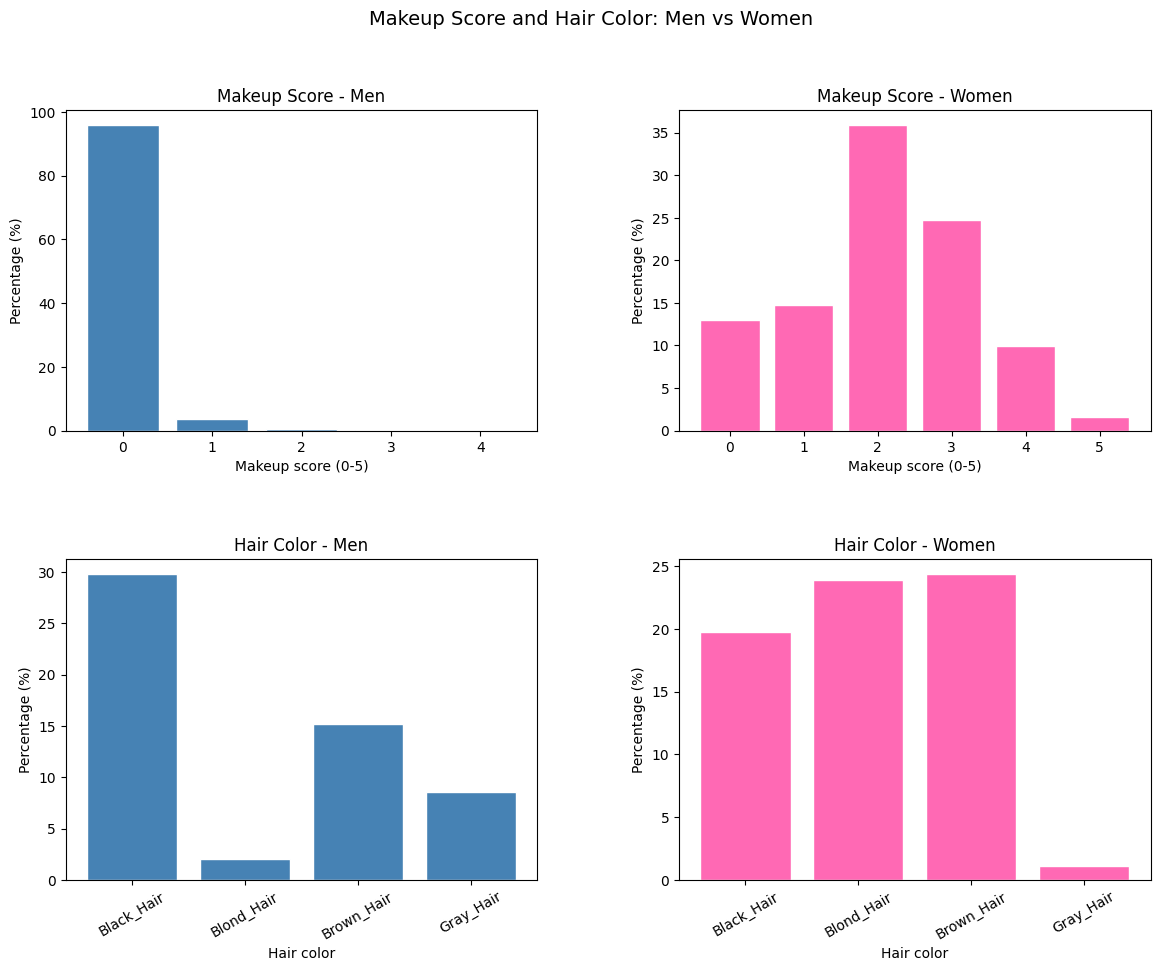

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Makeup Score and Hair Color: Men vs Women', fontsize=14)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

makeup_counts_men = men['makeup_score'].value_counts(normalize=True).sort_index() * 100
axes[0, 0].bar(makeup_counts_men.index, makeup_counts_men.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Makeup Score - Men')
axes[0, 0].set_xlabel('Makeup score (0-5)')
axes[0, 0].set_ylabel('Percentage (%)')

makeup_counts_women = women['makeup_score'].value_counts(normalize=True).sort_index() * 100
axes[0, 1].bar(makeup_counts_women.index, makeup_counts_women.values, color='hotpink', edgecolor='white')
axes[0, 1].set_title('Makeup Score - Women')
axes[0, 1].set_xlabel('Makeup score (0-5)')
axes[0, 1].set_ylabel('Percentage (%)')

hair_cols = ['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair']
men_hair = men[hair_cols].mean() * 100
axes[1, 0].bar(hair_cols, men_hair.values, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Hair Color - Men')
axes[1, 0].set_xlabel('Hair color')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].tick_params(axis='x', rotation=30)

women_hair = women[hair_cols].mean() * 100
axes[1, 1].bar(hair_cols, women_hair.values, color='hotpink', edgecolor='white')
axes[1, 1].set_title('Hair Color - Women')
axes[1, 1].set_xlabel('Hair color')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.show()

### 4) Attractive vs unattractive correlation with number of attributes and feminity score (for women)

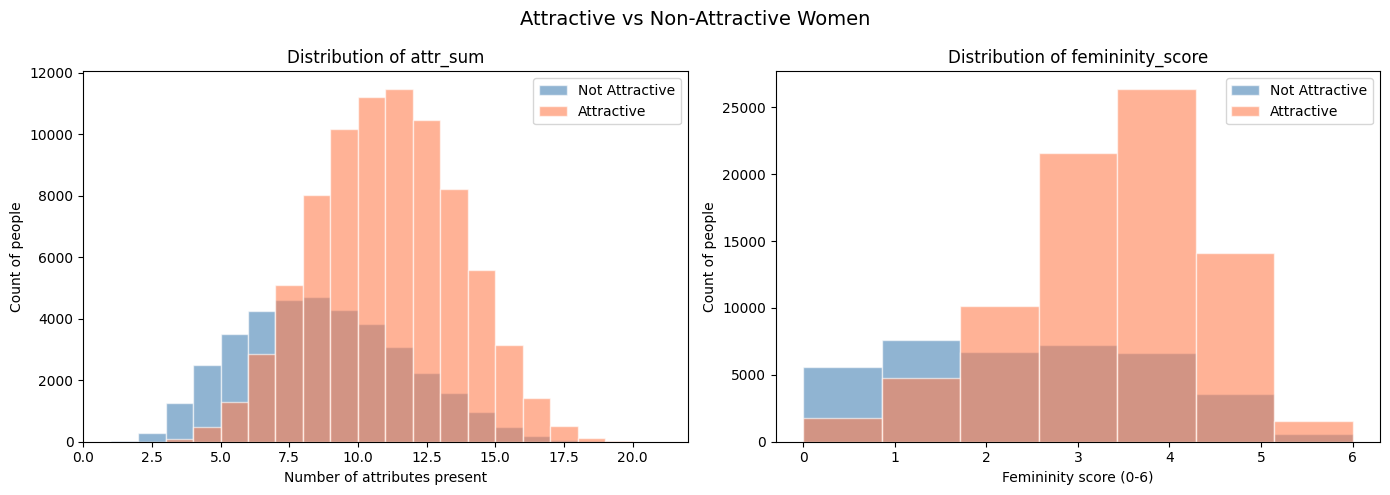

In [10]:
# 4. Attractive vs Non-Attractive: comparison of attr_sum and femininity_score
attractive = df_clean[(df_clean['Attractive'] == 1) & (df_clean['Male'] == 0)]
not_attractive = df_clean[(df_clean['Attractive'] == 0) & (df_clean['Male'] == 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attractive vs Non-Attractive Women', fontsize=14)

# attr_sum comparison
axes[0].hist(not_attractive['attr_sum'], bins=range(1, 22), 
             alpha=0.6, color='steelblue', edgecolor='white', label='Not Attractive')
axes[0].hist(attractive['attr_sum'], bins=range(1, 22), 
             alpha=0.6, color='coral', edgecolor='white', label='Attractive')
axes[0].set_title('Distribution of attr_sum')
axes[0].set_xlabel('Number of attributes present')
axes[0].set_ylabel('Count of people')
axes[0].legend()

# femininity_score comparison
axes[1].hist(not_attractive['femininity_score'], bins=7, 
             alpha=0.6, color='steelblue', edgecolor='white', label='Not Attractive')
axes[1].hist(attractive['femininity_score'], bins=7, 
             alpha=0.6, color='coral', edgecolor='white', label='Attractive')
axes[1].set_title('Distribution of femininity_score')
axes[1].set_xlabel('Femininity score (0-6)')
axes[1].set_ylabel('Count of people')
axes[1].legend()

plt.tight_layout()
plt.show()

## Hypothesis

**4 hypotheses:**

**Hypothesis 1:** Women with higher makeup_score are more likely to be labeled as Attractive than women with a low makeup_score. 
This relationship does not hold for men.

**Hypothesis 2:** Attractive women have a significantly higher femininity_score 
than attractive men. So, attractiveness of women is more strongly associated with feminine features than of men.

**Hypothesis 3:** Young women smile more often than young men. 
For older people this difference is smaller.

**Hypothesis 4:** Men with hair usually considered more attractive rather than bald men. This does not hold for women since very few women in the dataset are bald.

### Hypothesis 1

Among women, those with a higher `makeup_score` are more likely to be labeled 
as `attractive` than women with a low `makeup_score`. 
This relationship does not hold for men.

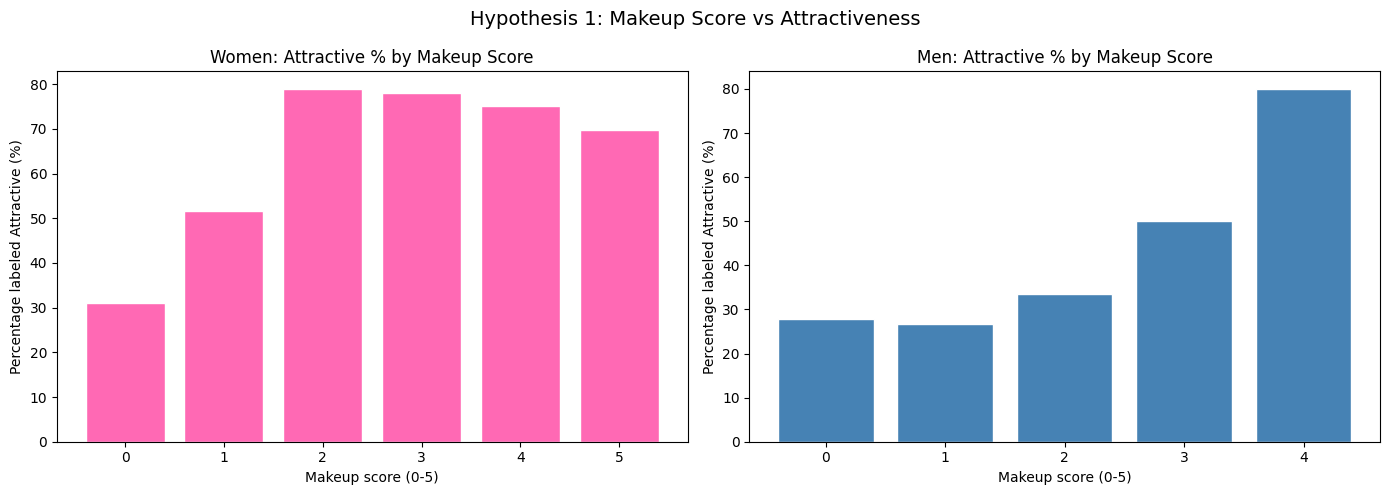

Women - Attractive % by makeup_score:
makeup_score
0    31.0
1    51.7
2    78.9
3    77.9
4    75.1
5    69.8
Name: Attractive, dtype: float64

Men - Attractive % by makeup_score:
makeup_score
0    27.9
1    26.6
2    33.4
3    50.0
4    80.0
Name: Attractive, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 1: Makeup Score vs Attractiveness', fontsize=14)

women_grouped = women.groupby('makeup_score')['Attractive'].mean() * 100
axes[0].bar(women_grouped.index, women_grouped.values, color='hotpink', edgecolor='white')
axes[0].set_title('Women: Attractive % by Makeup Score')
axes[0].set_xlabel('Makeup score (0-5)')
axes[0].set_ylabel('Percentage labeled Attractive (%)')

men_grouped = men.groupby('makeup_score')['Attractive'].mean() * 100
axes[1].bar(men_grouped.index, men_grouped.values, color='steelblue', edgecolor='white')
axes[1].set_title('Men: Attractive % by Makeup Score')
axes[1].set_xlabel('Makeup score (0-5)')
axes[1].set_ylabel('Percentage labeled Attractive (%)')

plt.tight_layout()
plt.show()

# Print statistics
print("Women - Attractive % by makeup_score:")
print(women_grouped.round(1))
print("\nMen - Attractive % by makeup_score:")
print(men_grouped.round(1))

### Result

Hypothesis 1 is **confirmed** for women: as makeup_score increases from 0 to 2, 
the percentage of women labeled Attractive rises sharply from 31% to 79%.
For men, the pattern also holds but the sample size for higher makeup scores is very small,
so this result is less reliable for males.

### Hypothesis 2

Attractive women have a significantly higher `femininity_score` than attractive men.
So, for women, attractiveness is more strongly associated with feminine features than for men.

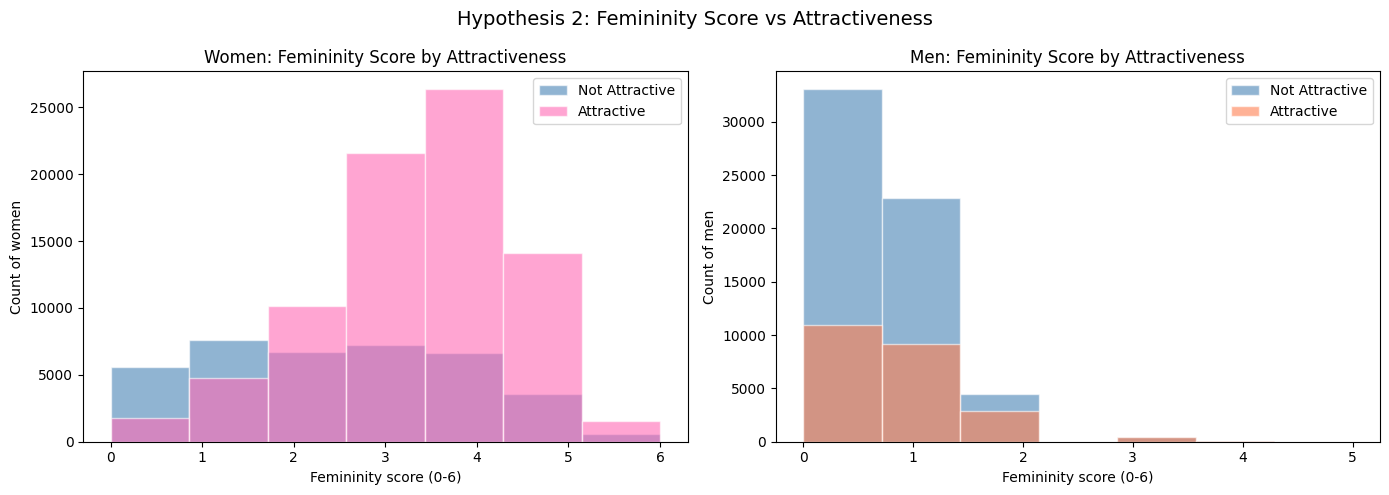

Attractive women - femininity_score mean: 3.43
Not attractive women - femininity_score mean: 2.39

Attractive men - femininity_score mean: 0.71
Not attractive men - femininity_score mean: 0.55


In [12]:
attractive_women = df_clean[(df_clean['Attractive'] == 1) & (df_clean['Male'] == 0)]
attractive_men = df_clean[(df_clean['Attractive'] == 1) & (df_clean['Male'] == 1)]
not_attractive_women = df_clean[(df_clean['Attractive'] == 0) & (df_clean['Male'] == 0)]
not_attractive_men = df_clean[(df_clean['Attractive'] == 0) & (df_clean['Male'] == 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 2: Femininity Score vs Attractiveness', fontsize=14)

axes[0].hist(not_attractive_women['femininity_score'], bins=7,
             alpha=0.6, color='steelblue', edgecolor='white', label='Not Attractive')
axes[0].hist(attractive_women['femininity_score'], bins=7,
             alpha=0.6, color='hotpink', edgecolor='white', label='Attractive')
axes[0].set_title('Women: Femininity Score by Attractiveness')
axes[0].set_xlabel('Femininity score (0-6)')
axes[0].set_ylabel('Count of women')
axes[0].legend()

axes[1].hist(not_attractive_men['femininity_score'], bins=7,
             alpha=0.6, color='steelblue', edgecolor='white', label='Not Attractive')
axes[1].hist(attractive_men['femininity_score'], bins=7,
             alpha=0.6, color='coral', edgecolor='white', label='Attractive')
axes[1].set_title('Men: Femininity Score by Attractiveness')
axes[1].set_xlabel('Femininity score (0-6)')
axes[1].set_ylabel('Count of men')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Attractive women - femininity_score mean:", attractive_women['femininity_score'].mean().round(2))
print("Not attractive women - femininity_score mean:", not_attractive_women['femininity_score'].mean().round(2))
print("\nAttractive men - femininity_score mean:", attractive_men['femininity_score'].mean().round(2))
print("Not attractive men - femininity_score mean:", not_attractive_men['femininity_score'].mean().round(2))

### Result

Hypothesis 2 is **confirmed**. Attractive women have a significantly higher femininity_score (mean: 3.43) compared to non-attractive women (mean: 2.39).
For men, the difference is much smaller (0.71 vs 0.55).
So, feminine features play a much stronger role in female attractiveness ratings rather than in male attractiveness ratings.

### Hypothesis 3

Young women `smile` more often than young men. 
Among older people this difference is smaller.

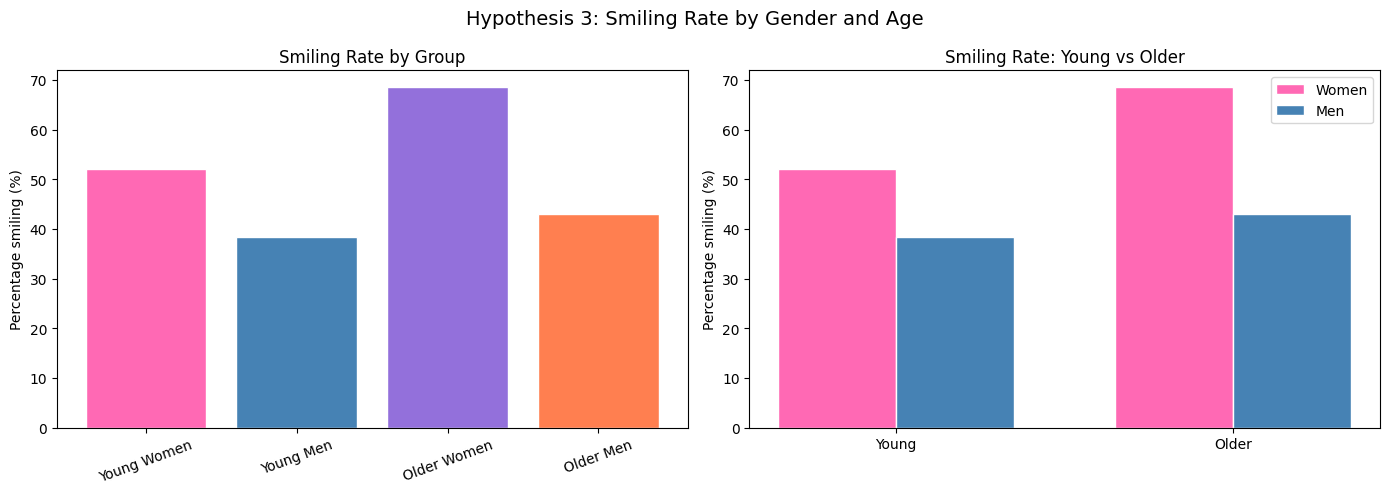

Young women smiling: 52.0%
Young men smiling: 38.3%
Older women smiling: 68.5%
Older men smiling: 43.0%


In [13]:
young_women = df_clean[(df_clean['Young'] == 1) & (df_clean['Male'] == 0)]
young_men = df_clean[(df_clean['Young'] == 1) & (df_clean['Male'] == 1)]
older_women = df_clean[(df_clean['Young'] == 0) & (df_clean['Male'] == 0)]
older_men = df_clean[(df_clean['Young'] == 0) & (df_clean['Male'] == 1)]

groups = ['Young Women', 'Young Men', 'Older Women', 'Older Men']
smiling_pct = [
    young_women['Smiling'].mean() * 100,
    young_men['Smiling'].mean() * 100,
    older_women['Smiling'].mean() * 100,
    older_men['Smiling'].mean() * 100
]
colors = ['hotpink', 'steelblue', 'mediumpurple', 'coral']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 3: Smiling Rate by Gender and Age', fontsize=14)

axes[0].bar(groups, smiling_pct, color=colors, edgecolor='white')
axes[0].set_title('Smiling Rate by Group')
axes[0].set_ylabel('Percentage smiling (%)')
axes[0].tick_params(axis='x', rotation=20)

x = [0, 1]
width = 0.35
axes[1].bar([i - width/2 for i in x], 
            [young_women['Smiling'].mean() * 100, older_women['Smiling'].mean() * 100],
            width, label='Women', color='hotpink', edgecolor='white')
axes[1].bar([i + width/2 for i in x],
            [young_men['Smiling'].mean() * 100, older_men['Smiling'].mean() * 100],
            width, label='Men', color='steelblue', edgecolor='white')
axes[1].set_title('Smiling Rate: Young vs Older')
axes[1].set_ylabel('Percentage smiling (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Young', 'Older'])
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Young women smiling: {young_women['Smiling'].mean()*100:.1f}%")
print(f"Young men smiling: {young_men['Smiling'].mean()*100:.1f}%")
print(f"Older women smiling: {older_women['Smiling'].mean()*100:.1f}%")
print(f"Older men smiling: {older_men['Smiling'].mean()*100:.1f}%")

### Result

Hypothesis 3 is **partially confirmed**. Young women smile ~13.7% more often than young men (52.0% vs. 38.3%). However, the second part of the hypothesis was incorrect and among older people the gap is even larger - 25.5% (68.5% vs 43.0%), not smaller as was expected.

### Hypothesis 4

Bald men are less likely to be labeled as `attractive` than men with hair.
This pattern does not appear among women since very few women in the dataset are bald.

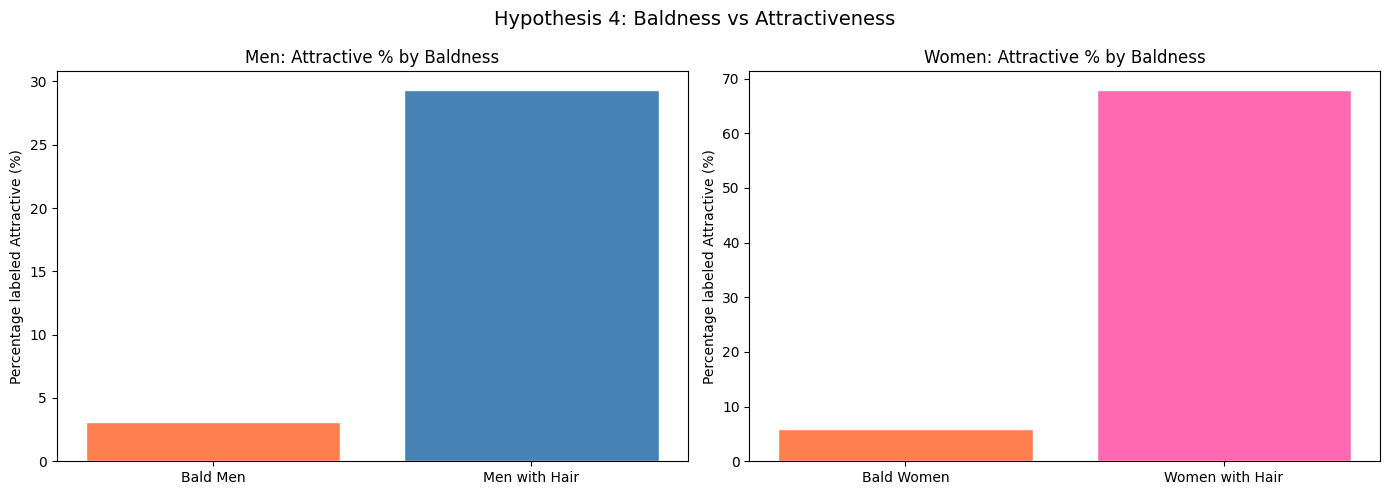

Bald men - Attractive: 3.1%
Men with hair - Attractive: 29.3%

Bald women - Attractive: 5.9%
Women with hair - Attractive: 67.9%

Number of bald women in dataset: 17
Number of bald men in dataset: 4530


In [14]:
bald_men = df_clean[(df_clean['Bald'] == 1) & (df_clean['Male'] == 1)]
haired_men = df_clean[(df_clean['Bald'] == 0) & (df_clean['Male'] == 1)]
bald_women = df_clean[(df_clean['Bald'] == 1) & (df_clean['Male'] == 0)]
haired_women = df_clean[(df_clean['Bald'] == 0) & (df_clean['Male'] == 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 4: Baldness vs Attractiveness', fontsize=14)

groups_men = ['Bald Men', 'Men with Hair']
values_men = [bald_men['Attractive'].mean() * 100, 
              haired_men['Attractive'].mean() * 100]
axes[0].bar(groups_men, values_men, color=['coral', 'steelblue'], edgecolor='white')
axes[0].set_title('Men: Attractive % by Baldness')
axes[0].set_ylabel('Percentage labeled Attractive (%)')

groups_women = ['Bald Women', 'Women with Hair']
values_women = [bald_women['Attractive'].mean() * 100,
                haired_women['Attractive'].mean() * 100]
axes[1].bar(groups_women, values_women, color=['coral', 'hotpink'], edgecolor='white')
axes[1].set_title('Women: Attractive % by Baldness')
axes[1].set_ylabel('Percentage labeled Attractive (%)')

plt.tight_layout()
plt.show()

print(f"Bald men - Attractive: {bald_men['Attractive'].mean()*100:.1f}%")
print(f"Men with hair - Attractive: {haired_men['Attractive'].mean()*100:.1f}%")
print(f"\nBald women - Attractive: {bald_women['Attractive'].mean()*100:.1f}%")
print(f"Women with hair - Attractive: {haired_women['Attractive'].mean()*100:.1f}%")
print(f"\nNumber of bald women in dataset: {len(bald_women)}")
print(f"Number of bald men in dataset: {len(bald_men)}")

### Result

Hypothesis 4 is **confirmed** for men: bald men are labeled as attractive  significantly less often than men with hair (3.1% vs 29.3%).
But he same pattern appears even stronger among women (5.9% vs 67.9%), however the sample of bald women is very small (only 17 out of 202,599 images), that is why this result for women is unreliable.